---
title: Computer Vision <code>assignment-2</code>
descrption: Computer Vision Assignment-2
author: Poornima Bhatia
date: 'October 21, 2024'
categories: ['Harris and Hessian Corner Detector' , 'Gaussian & Laplacian pyramid']
image: True
foramt:
html:
code-fold: true
---

# Task

### Pre-defined code

In [1]:
# # Mounting google drive
# from google.colab import drive
# drive.mount('/content/drive')

# Downloading all the required libraries


# Importing all the required libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import style
from glob import glob
from natsort import natsorted
from tqdm import tqdm
style.use('ggplot')

In [2]:
# Loading all the images in the drive
gt_images = []

for files in tqdm(natsorted(glob('./images/B/*'))):
    gt_images.append(cv2.imread(files, 1))

gt_images = np.array(gt_images) # Only possible because all images are of same size

100%|██████████| 6/6 [00:00<00:00, 203.66it/s]


In [3]:
def show_image_grid(images, M, N, title='Title', figsize=8):
    # Assuming 'images' is a numpy array of shape (num_images, height, width, channels)
    if M==1:
        row_size = figsize
        col_size = figsize//4
    elif N==1:
        row_size = figsize//4
        col_size = figsize
    else:
        row_size, col_size = figsize, figsize

    fig, axes = plt.subplots(M, N, figsize=(row_size, col_size))

    if len(images.shape) < 4:
        images = np.expand_dims(images.copy(), axis=0)

    fig.suptitle(title)
    for i in range(M):
        for j in range(N):
            if M==1 and N==1:
                ax = axes
            elif M == 1 or N==1:
                ax = axes[max(i, j)]
            else:
                ax = axes[i, j]
            index = i * N + j
            if index < images.shape[0]:
                ax.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
            ax.axis('off')
    plt.tight_layout()
    plt.show()

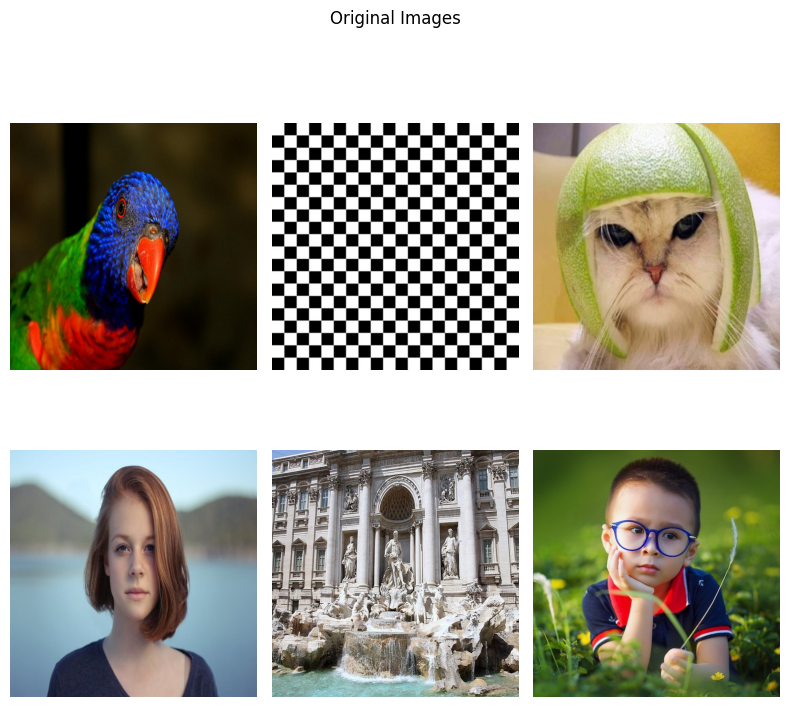

In [4]:
show_image_grid(gt_images, 2, 3, 'Original Images', figsize=8)

### Q1 [2 Marks]

Implement Gaussian Pyramid Downsampling method from scratch.Compare it with Opencv resize method. What difference do you observe when you resize an image with Gaussian Pyramid approach and Opencv approach.

References:
1. [Gaussian & Laplacian pyramid	construction](https://www.cs.toronto.edu/~mangas/teaching/320/slides/CSC320L10.pdf)
2. [Multi-Scale Representation](https://medium.com/jun94-devpblog/cv-4-multi-scale-representation-gaussian-and-laplacian-pyramid-527ca4c4831c)

In [5]:
def pad_image_to_divisible(image, K, pad_value=0):
    # Get the original image dimensions
    h, w = image.shape[:2]

    # Calculate the padding needed for height and width
    pad_h = (K - (h % K)) % K  # Padding needed for height
    pad_w = (K - (w % K)) % K  # Padding needed for width

    # Compute the padding to add to top/bottom and left/right
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    # Pad the image: (top, bottom), (left, right), and (no padding on channels)
    if len(image.shape) == 3:  # For RGB images
        padded_image = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
                              mode='constant', constant_values=pad_value)
    else:  # For grayscale images
        padded_image = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)),
                              mode='constant', constant_values=pad_value)

    return padded_image

In [6]:
def gaussian_kernel(size, sigma=1):
    kernel = np.fromfunction(
        lambda x, y: (1 / (2 * np.pi * sigma**2)) *
                      np.exp(-((x - (size - 1) / 2)**2 + (y - (size - 1) / 2)**2) / (2 * sigma**2)),
        (size, size)
    )
    return kernel / np.sum(kernel)  # Normalize the kernel

def convolve2d(image, kernel):
    kernel_height, kernel_width = kernel.shape
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    if len(image.shape) == 2:
        padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
        output = np.zeros_like(image)
        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                output[i, j] = np.sum(padded_image[i:i + kernel_height, j:j + kernel_width] * kernel)
    elif len(image.shape) == 3:
        padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width), (0, 0)), mode='constant')
        output = np.zeros_like(image)
        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                for c in range(image.shape[2]):
                    output[i, j, c] = np.sum(padded_image[i:i + kernel_height, j:j + kernel_width, c] * kernel)
    return output

def gaussian_pyramid(image, levels):
    pyramid = [image]
    for i in range(levels - 1):
        # Apply Gaussian blur and downsample by a factor of 2

        # Write code here
        # Apply Gaussian blur
        kernel = gaussian_kernel(size=5, sigma=1)
        blurred_image = convolve2d(pyramid[-1], kernel)
        # Downsample by taking every second pixel
        downsampled_image = blurred_image[::2, ::2]
        image = pad_image_to_divisible(downsampled_image, pyramid[0].shape[0])
        pyramid.append(image)

    return np.array(pyramid)


def opencv_resize(inp_image, levels):
    pyramid = []
    h, w    = inp_image.shape[:2]
    for i in range(levels):
        # Apply Gaussian blur and downsample by a factor of 2
        # Write code here
        image = cv2.resize(inp_image, (h//2**i, w//2**i))

        image = pad_image_to_divisible(image, min(h, w))
        pyramid.append(image)

    return np.array(pyramid)

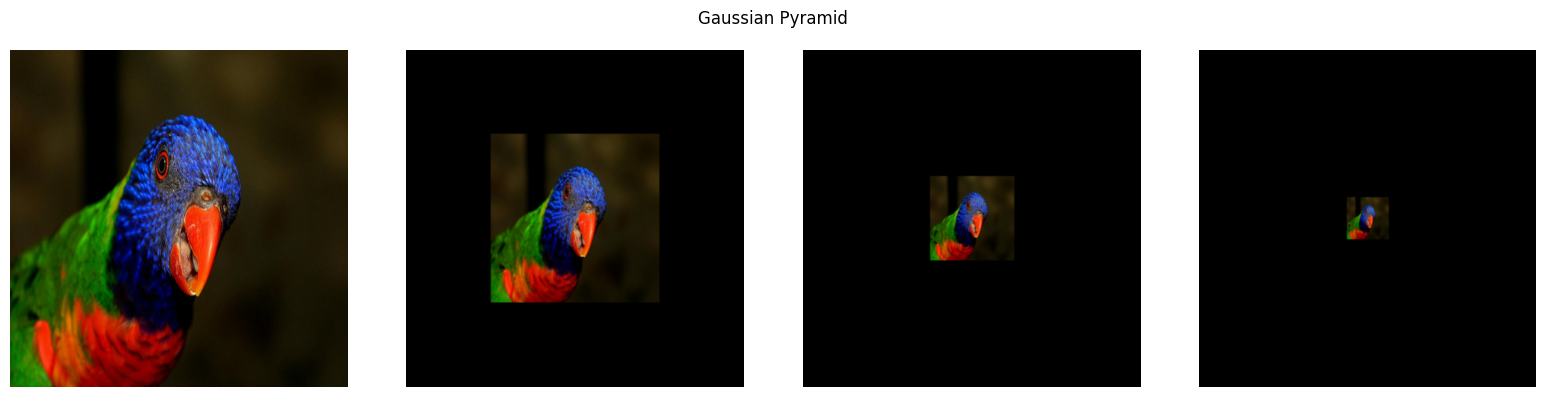

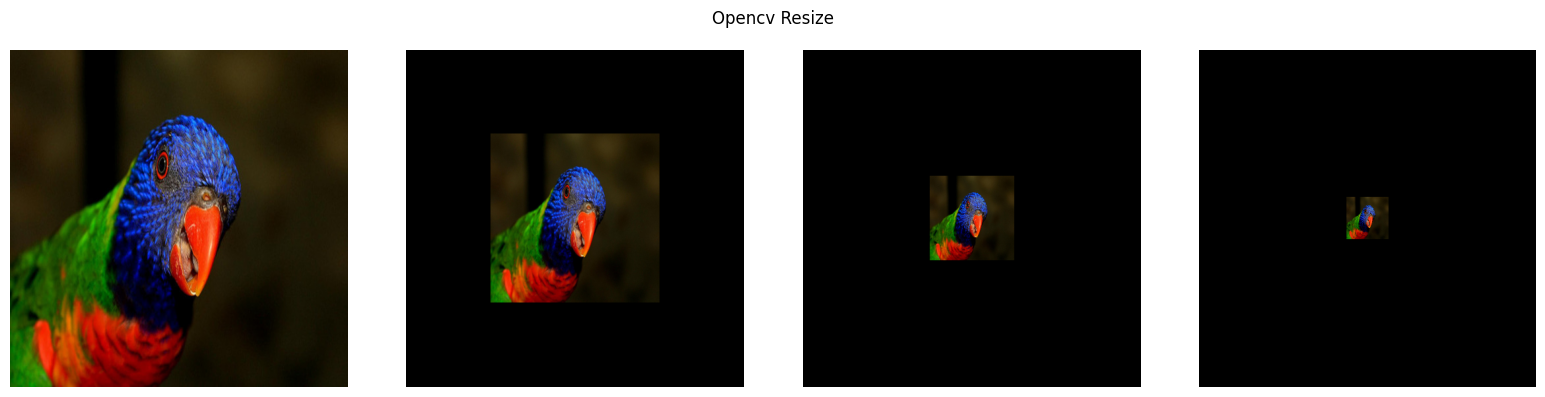

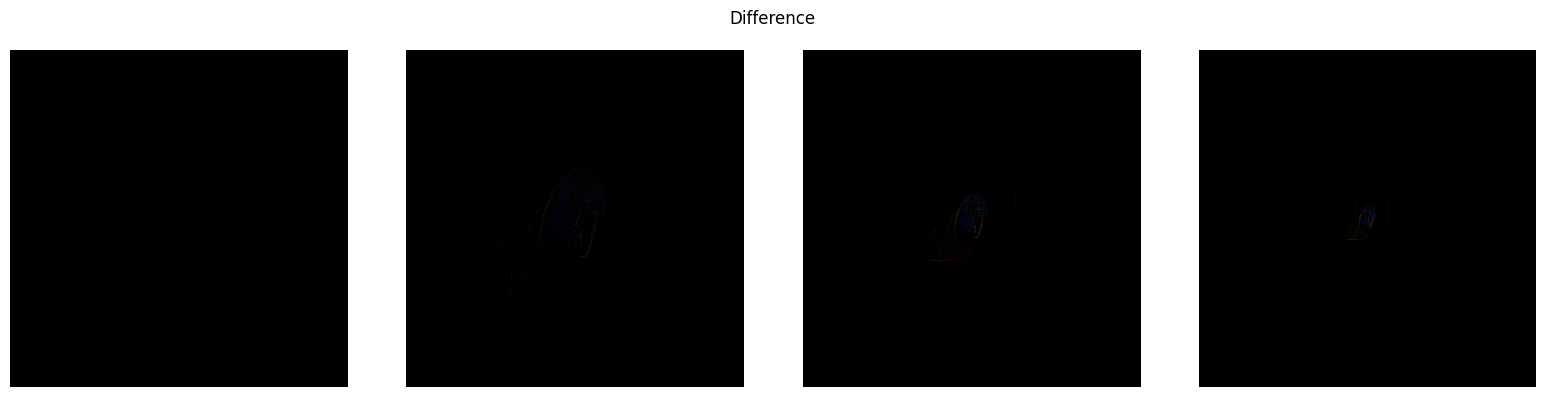

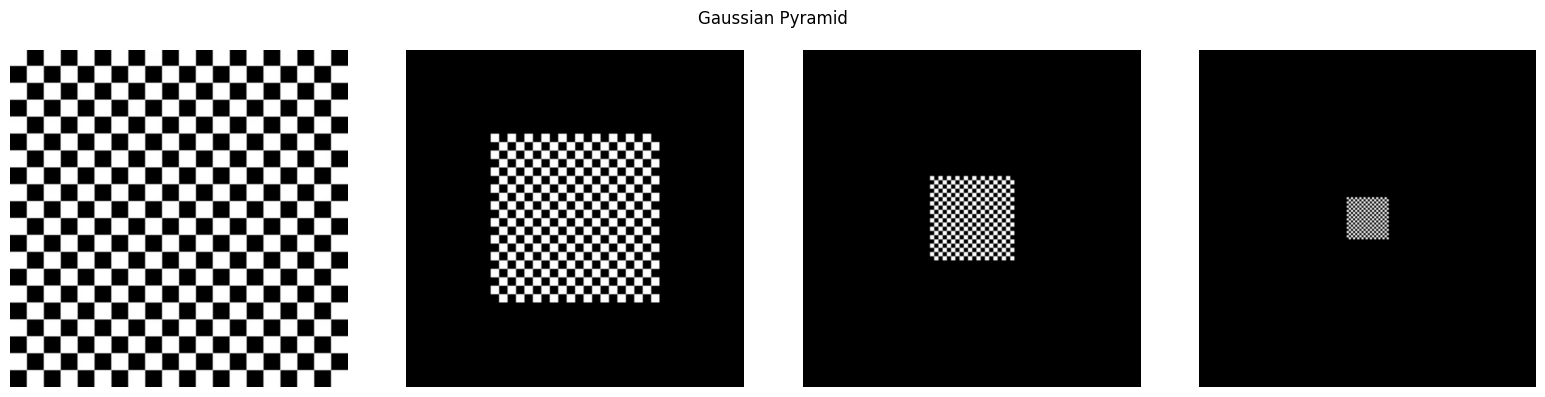

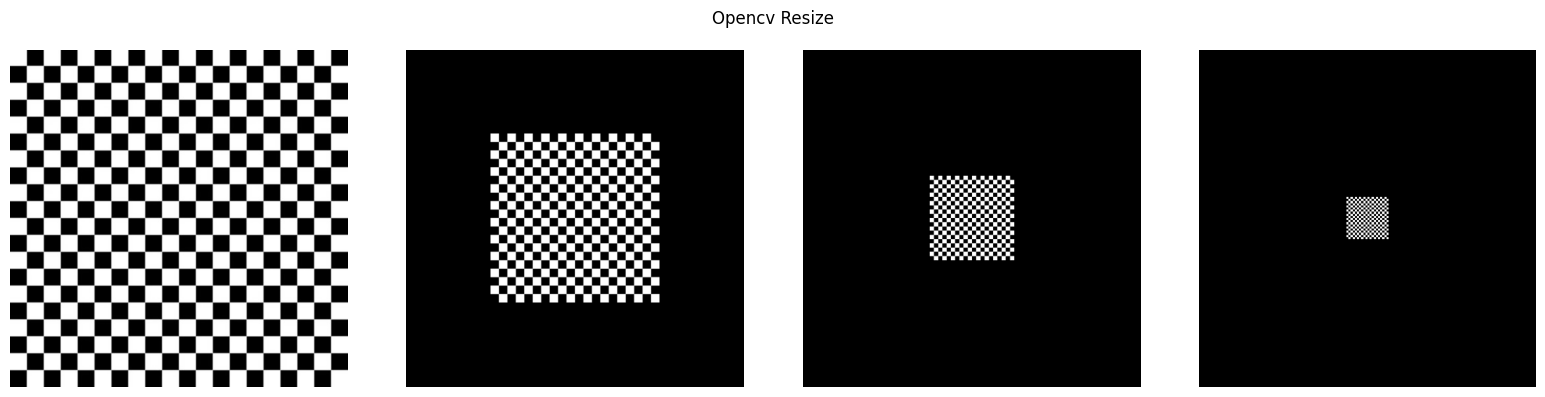

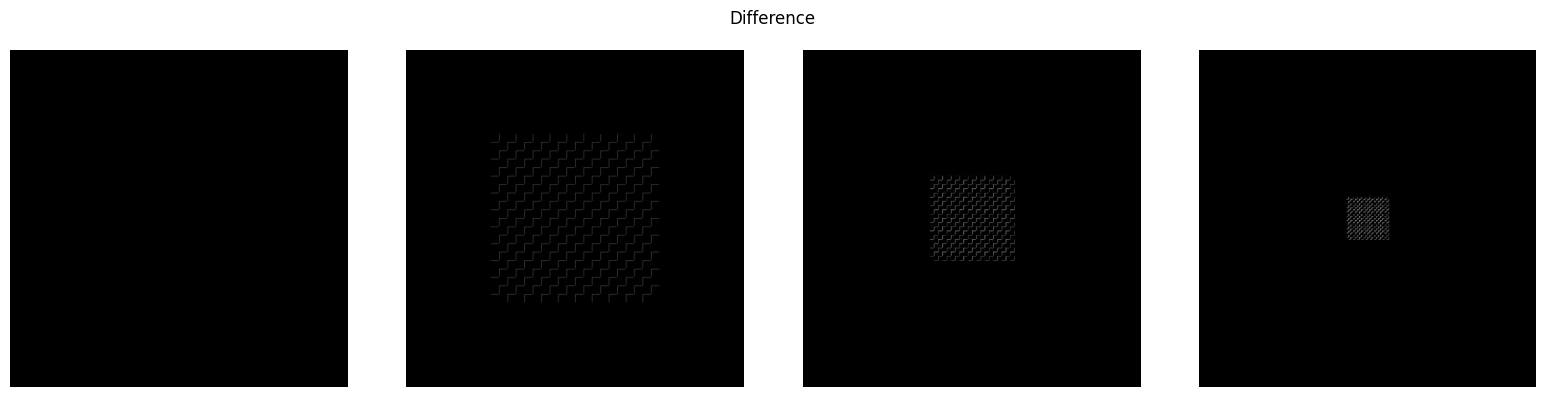

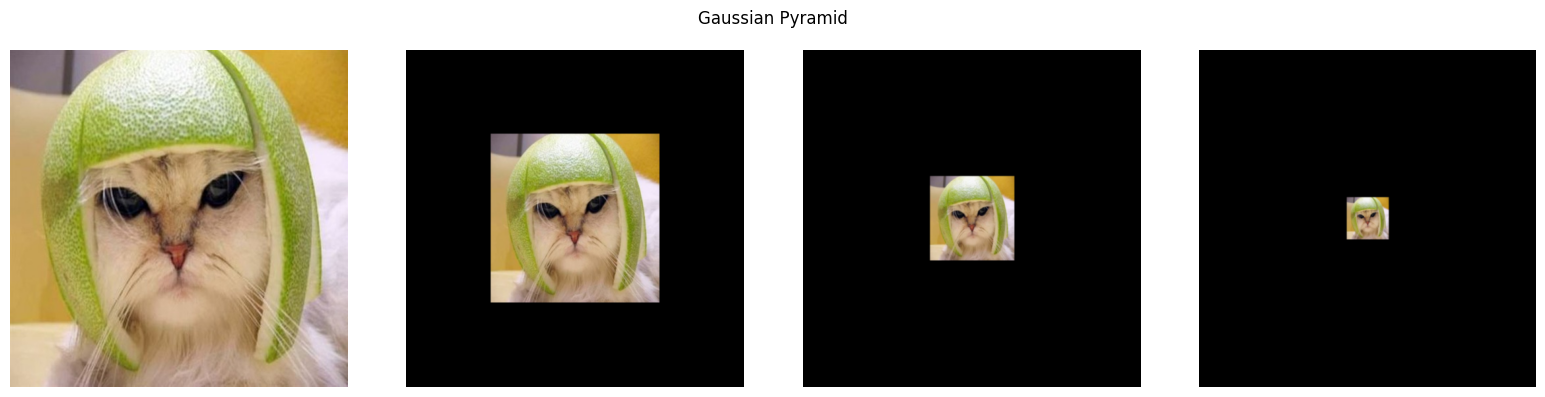

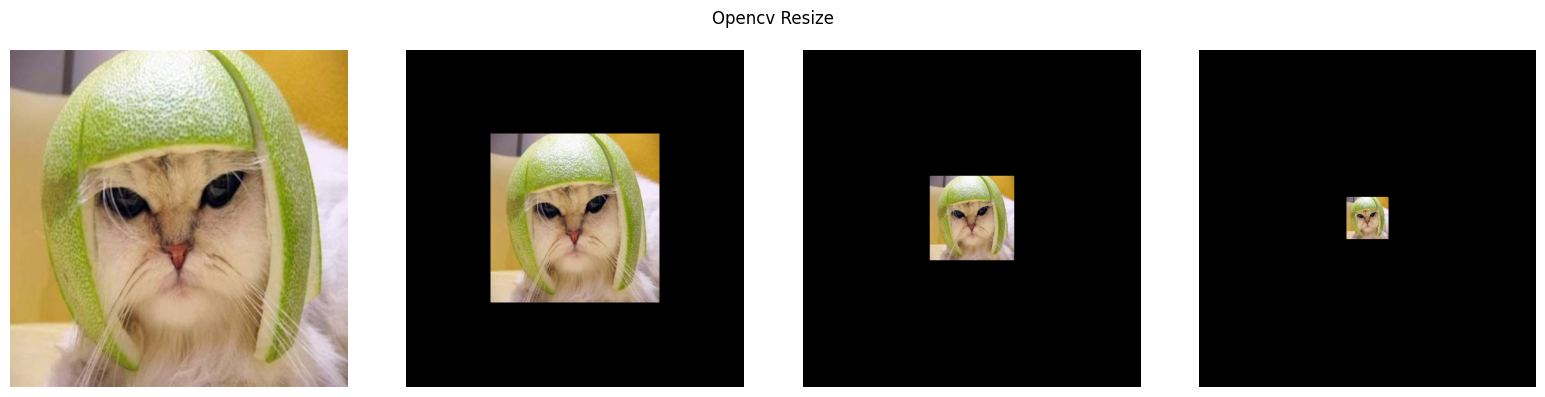

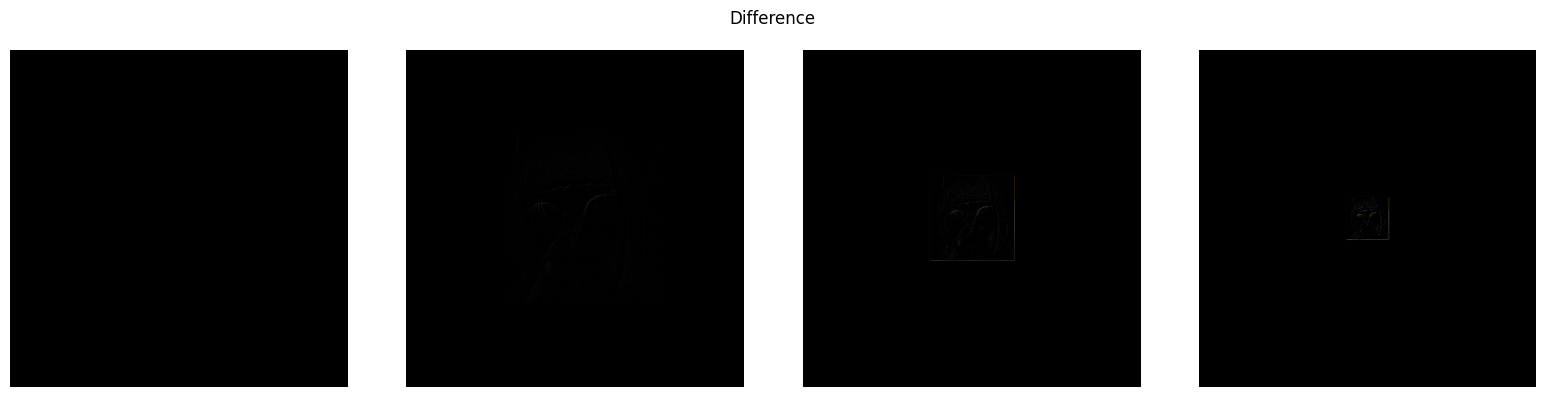

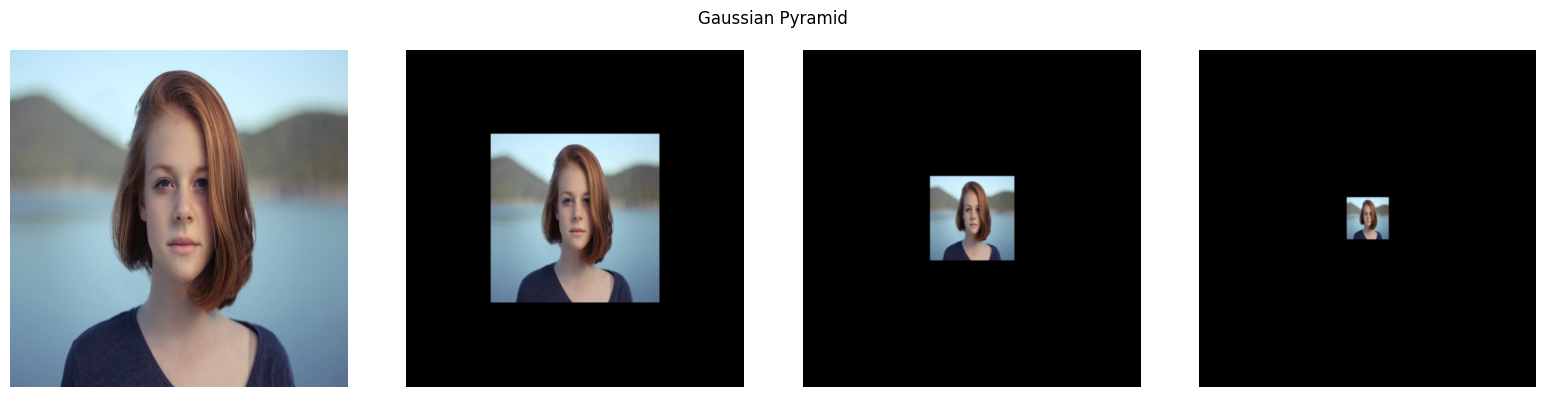

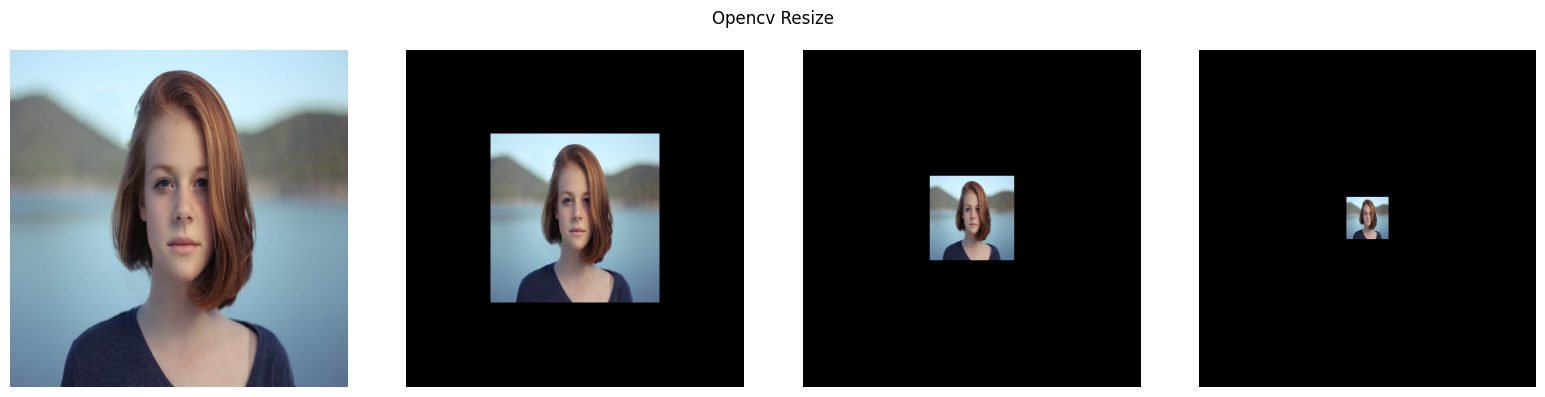

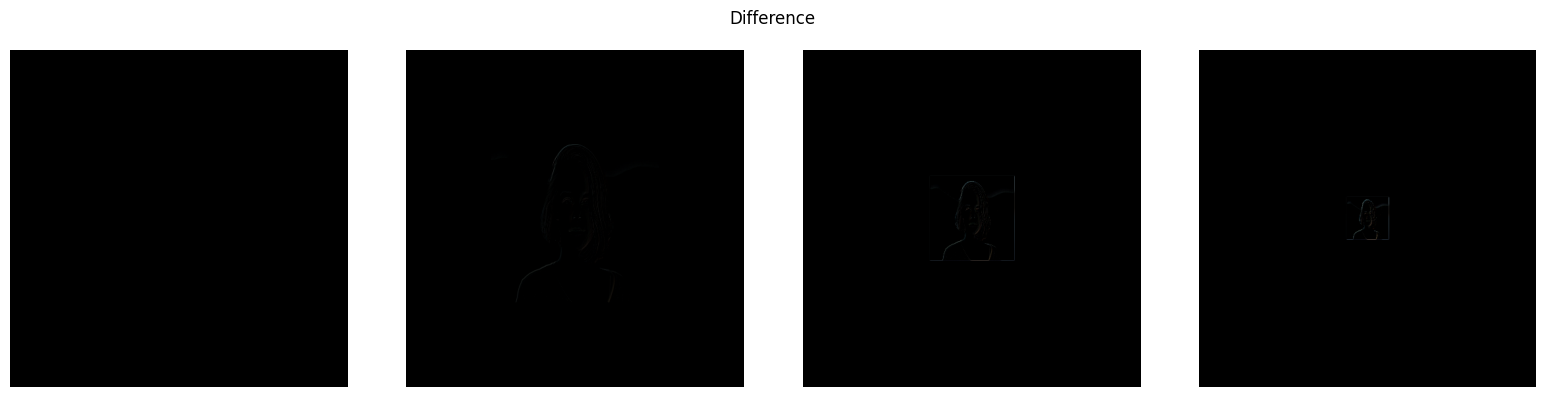

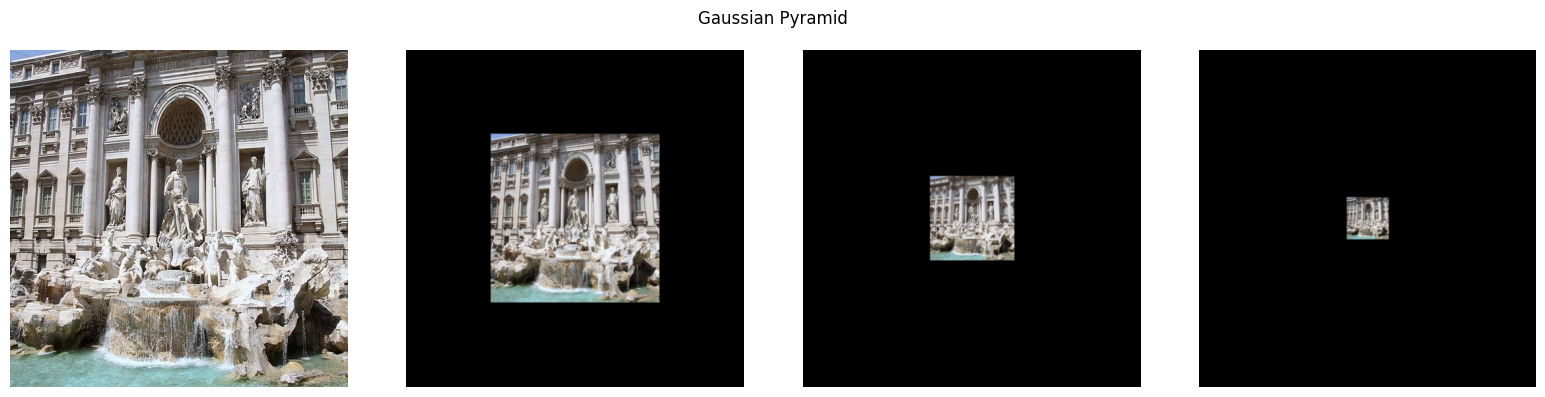

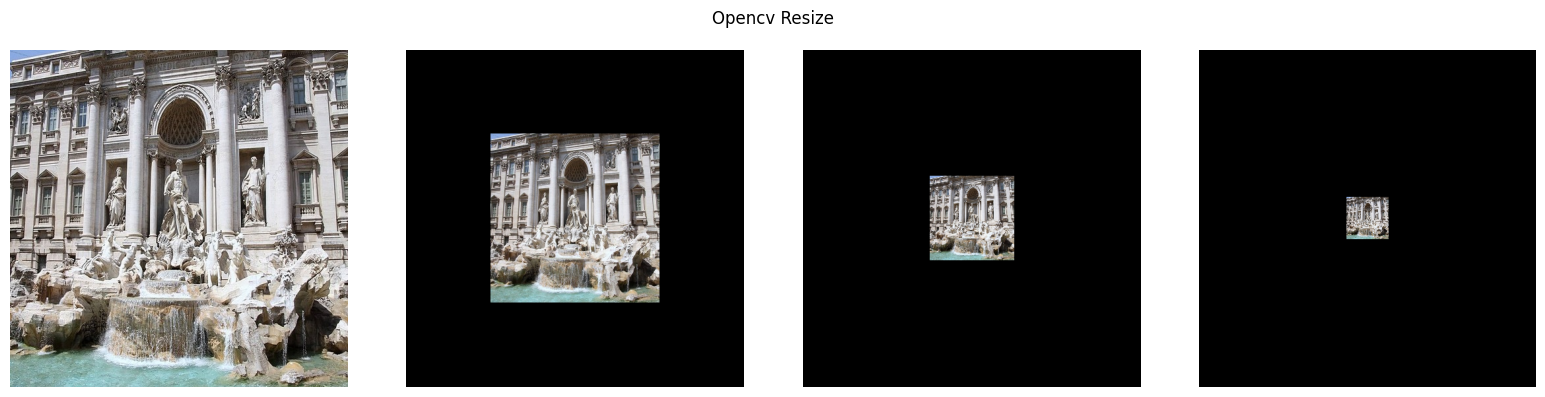

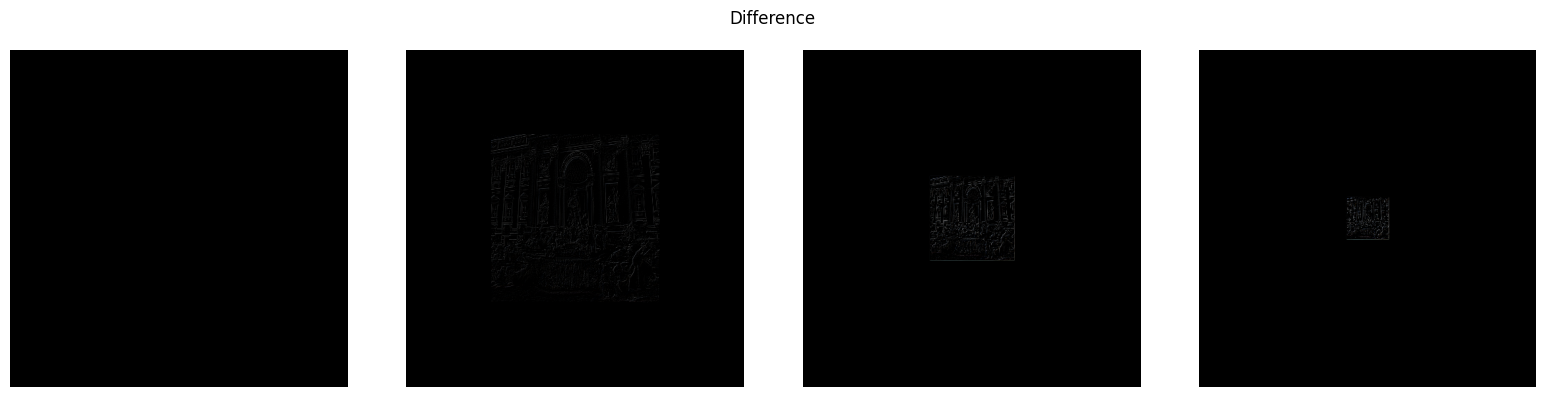

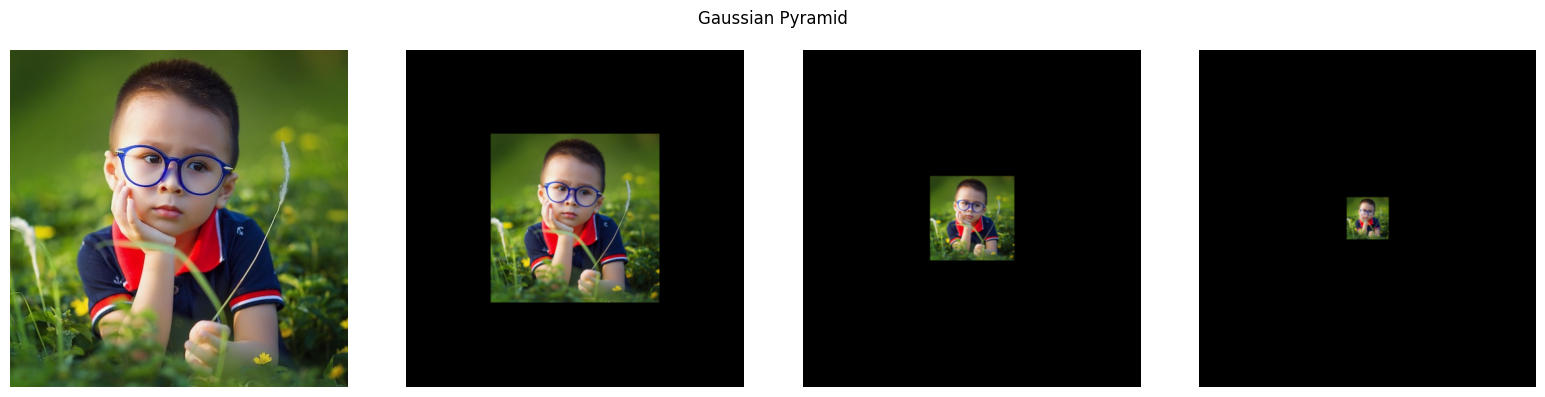

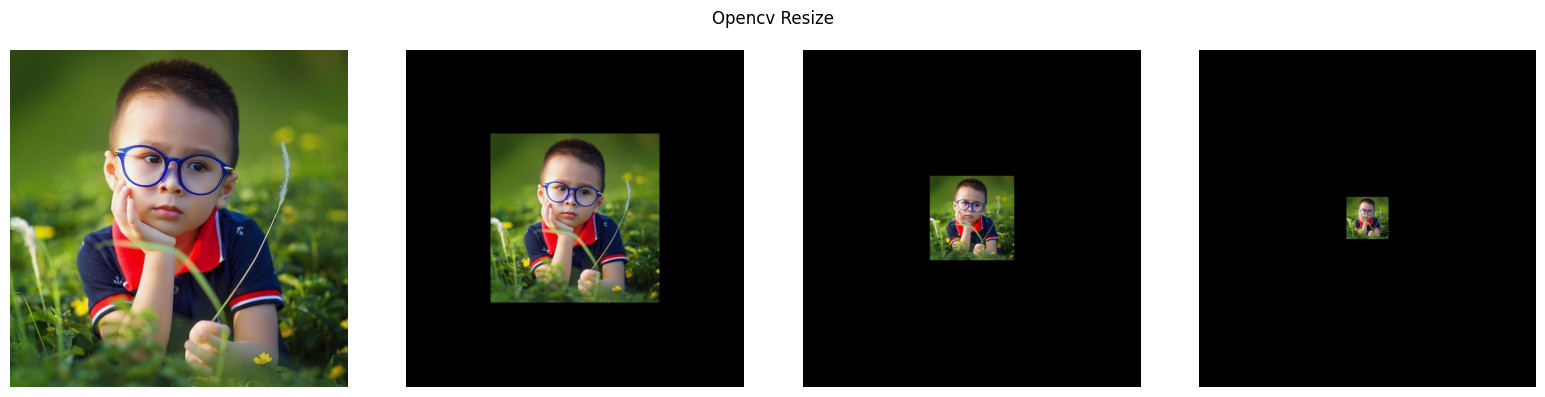

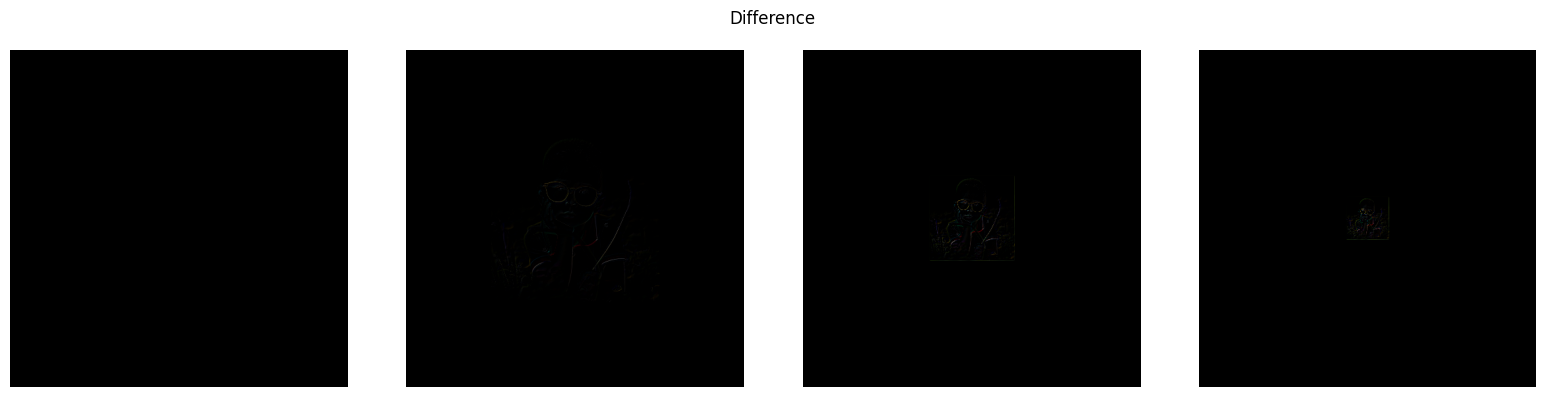

In [7]:
for idx, image in enumerate(gt_images):

    # Generate pyramid of images for matching
    s_image_pyramids = gaussian_pyramid(image, levels=4)
    s_image_opecv_resize = opencv_resize(image, levels=4)

    diff = []
    for gauss_img, open_img in zip(s_image_pyramids, s_image_opecv_resize):
        diff.append(cv2.subtract(gauss_img, open_img))
    diff = np.array(diff)

    show_image_grid(s_image_pyramids, 1, 4, 'Gaussian Pyramid', figsize=16)
    show_image_grid(s_image_opecv_resize, 1, 4, 'Opencv Resize', figsize=16)
    show_image_grid(diff, 1, 4, 'Difference', figsize=16)

### Q2 [4 Marks]

You have to implement image blending technique using Laplacian Pyramids from scratch.

You can use following functions from opencv/scipy:

* convolution
* cv2.subtract
* cv2.add
* cv2.resize
* padding

You can follow this article for more explanation:

1. [Image Blending Using Laplacian Pyramids](https://becominghuman.ai/image-blending-using-laplacian-pyramids-2f8e9982077f)

In [8]:
def gaussian_kernel(size, sigma):
    kernel = np.fromfunction(
        lambda x, y: (1 / (2 * np.pi * sigma**2)) *
                      np.exp(-((x - (size - 1) / 2)**2 + (y - (size - 1) / 2)**2) / (2 * sigma**2)),
        (size, size)
    )
    return kernel / np.sum(kernel)  # Normalize the kernel

def convolve2d(image, kernel):
    kernel_height, kernel_width = kernel.shape
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    if len(image.shape) == 2:
        padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
        output = np.zeros_like(image)
        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                output[i, j] = np.sum(padded_image[i:i + kernel_height, j:j + kernel_width] * kernel)
    elif len(image.shape) == 3:
        padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width), (0, 0)), mode='constant')
        output = np.zeros_like(image)
        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                for c in range(image.shape[2]):
                    output[i, j, c] = np.sum(padded_image[i:i + kernel_height, j:j + kernel_width, c] * kernel)
    return output

def pad_image(image, pad_value):
    rows, cols = image.shape[:2]
    pad_rows = (pad_value - rows % pad_value) % pad_value
    pad_cols = (pad_value - cols % pad_value) % pad_value
    padded_image = np.pad(image, ((0, pad_rows), (0, pad_cols), (0, 0)), mode='constant')
    return padded_image

def gaussian_pyramid(image, levels):
    pyramid = [image]
    for _ in range(levels - 1):
        kernel = gaussian_kernel(size=5, sigma=1.0)
        blurred_image = convolve2d(pyramid[-1], kernel)
        downsampled_image = blurred_image[::2, ::2]
        pyramid.append(downsampled_image)
    return pyramid

def laplacian_pyramid(image, levels):
    gaussian_pyr = gaussian_pyramid(image, levels)
    laplacian_pyr = []

    for i in range(levels - 1):
        upsampled_image = cv2.resize(gaussian_pyr[i + 1], (gaussian_pyr[i].shape[1], gaussian_pyr[i].shape[0]),interpolation=cv2.INTER_CUBIC)
        upsampled_image = convolve2d(upsampled_image, gaussian_kernel(size=5, sigma=1))
        upsampled_image = upsampled_image.astype(gaussian_pyr[i].dtype)
        laplacian = cv2.subtract(gaussian_pyr[i], upsampled_image)
        laplacian_pyr.append(laplacian)
    laplacian_pyr.append(gaussian_pyr[-1])
    return laplacian_pyr

def reconstruct_from_pyramid(pyramid, kernel):
    image = pyramid[-1]
    for i in range(len(pyramid) - 2, -1, -1):
        image = cv2.resize(image, (pyramid[i].shape[1], pyramid[i].shape[0]), interpolation=cv2.INTER_CUBIC)
        image = convolve2d(image, kernel)
        image = cv2.add(image, pyramid[i])
    return image

def manual_blend(image_a, image_b):
    assert image_a.shape == image_b.shape, "Images must have the same shape for blending."
    mask = np.zeros_like(image_a, dtype=np.float32)
    mask[:, :image_a.shape[1] // 2] = 1
    blended = image_a * mask + image_b * (1 - mask)
    return blended

def laplacian_pyramid_blend_images(image_a, image_b, levels=4):
    pad_value = 2 ** levels
    image_a = pad_image(image_a, pad_value)
    image_b = pad_image(image_b, pad_value)
    kernel = gaussian_kernel(size=5, sigma=1.0)
    lap_a = laplacian_pyramid(image_a, levels)
    lap_b = laplacian_pyramid(image_b, levels)

    blended_pyramid = []
    for la, lb in zip(lap_a, lap_b):
        blended = manual_blend(la, lb)
        blended_pyramid.append(blended)
    blended_image = reconstruct_from_pyramid(blended_pyramid, kernel)
    blended_image = np.clip(blended_image, 0, 255).astype(np.uint8)
    return blended_image

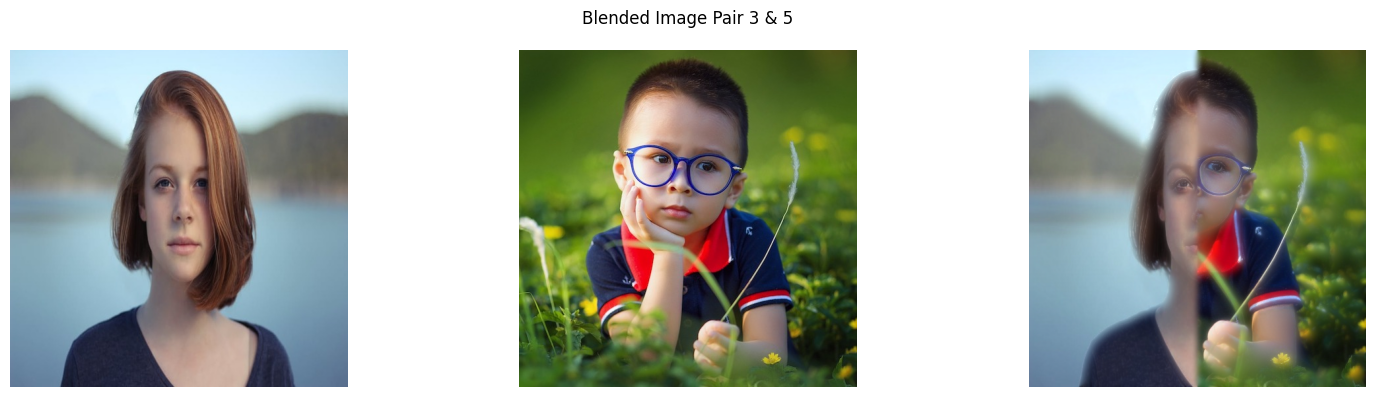

In [9]:
blended_image = laplacian_pyramid_blend_images(gt_images[3], gt_images[5])
collage = np.array([gt_images[3], gt_images[5], blended_image])
show_image_grid(collage, 1, 3, 'Blended Image Pair 3 & 5', figsize=16)

### Q3 [4 Marks]

Implement Harris and Hessian Corner Detector algorithm from scratch.

You can use following functions from opencv/scipy:

* convolution
* cv2.subtract
* cv2.add
* cv2.resize
* padding

You can follow this article for more explanation:

1. [Harris and Hessian Corner Detector](https://medium.com/jun94-devpblog/cv-10-local-feature-descriptors-harris-and-hessian-corner-detector-7d524888abfd)

In [10]:
def gaussian_kernel(size, sigma=1):
    kernel = np.fromfunction(
        lambda x, y: (1 / (2 * np.pi * sigma**2)) *
                      np.exp(-((x - (size - 1) / 2)**2 + (y - (size - 1) / 2)**2) / (2 * sigma**2)),
        (size, size)
    )
    return kernel / np.sum(kernel)  # Normalize the kernel

def convolve2d(image, kernel):
    kernel_height, kernel_width = kernel.shape
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    if len(image.shape) == 2:
        padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
        output = np.zeros_like(image)
        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                output[i, j] = np.sum(padded_image[i:i + kernel_height, j:j + kernel_width] * kernel)
    elif len(image.shape) == 3:
        padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width), (0, 0)), mode='constant')
        output = np.zeros_like(image)
        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                for c in range(image.shape[2]):
                    output[i, j, c] = np.sum(padded_image[i:i + kernel_height, j:j + kernel_width, c] * kernel)
    return output

def compute_gradients(image):
    sobel_x = np.array([[1, 0, -1],
                        [2, 0, -2],
                        [1, 0, -1]])

    sobel_y = np.array([[1, 2, 1],
                        [0, 0, 0],
                        [-1, -2, -1]])

    Ix = convolve2d(image, sobel_x)
    Iy = convolve2d(image, sobel_y)
    return Ix, Iy

def compute_harris_response(Ix, Iy, k=0.04):
    Ixx = Ix ** 2
    Ixy = Ix * Iy
    Iyy = Iy ** 2
    Gxx = convolve2d(Ixx, gaussian_kernel(5, sigma=1))
    Gxy = convolve2d(Ixy, gaussian_kernel(5, sigma=1))
    Gyy = convolve2d(Iyy, gaussian_kernel(5, sigma=1))
    det_M = (Gxx * Gyy) - (Gxy ** 2)
    trace_M = Gxx + Gyy
    R = det_M - k * (trace_M ** 2)
    return R

def compute_hessian_response(Ix, Iy):
    Ixx = convolve2d(Ix, gaussian_kernel(5, sigma=1))
    Ixy = convolve2d(Ix, Iy)
    Iyy = convolve2d(Iy, gaussian_kernel(5, sigma=1))
    H = (Ixx * Iyy) - (Ixy ** 2)
    return H

def non_maximum_suppression(corner_response):
    corners = np.zeros_like(corner_response)
    for i in range(1, corner_response.shape[0] - 1):
        for j in range(1, corner_response.shape[1] - 1):
            if np.any(corner_response[i-1:i+2, j-1:j+2] > 0):
                corners[i, j] = 255
    return corners.astype(np.uint8)

def detect_harris_corner(image, gaussian_size=5, k=0.04 , threshold=0.01):
    original_image = image.copy()
    if len(image.shape) == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        image_gray = image
    image_gray = image_gray.astype(np.float32) / 255.0
    Ix, Iy = compute_gradients(image_gray)
    R = compute_harris_response(Ix, Iy, k)
    corners = np.zeros_like(R)
    corners[R > threshold * R.max()] = 255
    corners = non_maximum_suppression(corners)
    threshold_value = threshold * np.max(R)
    corners[corners < threshold_value] = 0

    corner_image = original_image.copy()
    corner_image[corners > 0] = [0, 0, 255]

    return corner_image

def detect_hessian_corner(image, gaussian_size=5, threshold=0.01):
    original_image = image.copy()
    if len(image.shape) == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        image_gray = image
    image_gray = image_gray.astype(np.float32) / 255.0
    Ix, Iy = compute_gradients(image_gray)
    H = compute_hessian_response(Ix, Iy)
    corners = np.zeros_like(H)
    corners[H > threshold * H.max()] = 255
    corners = non_maximum_suppression(corners)
    corner_image = original_image.copy()
    corner_image[corners > 0] = [255, 0, 0]
    return corner_image

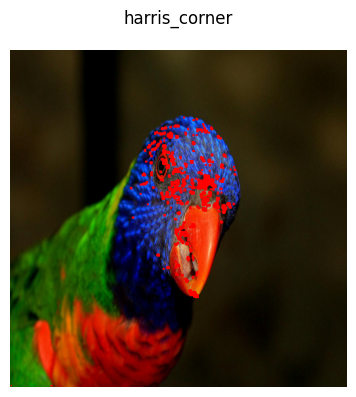

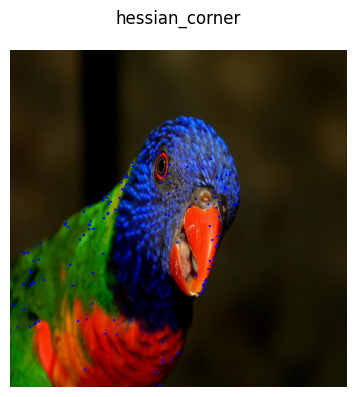

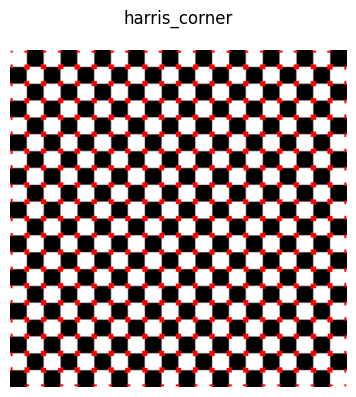

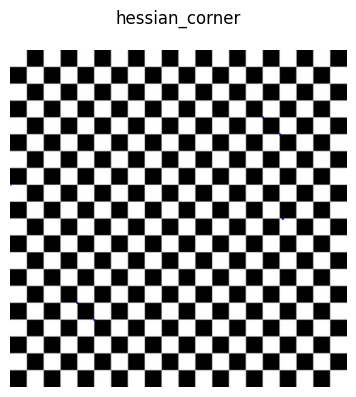

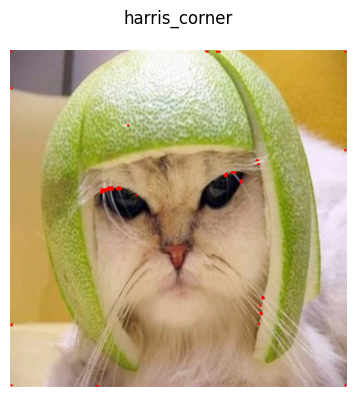

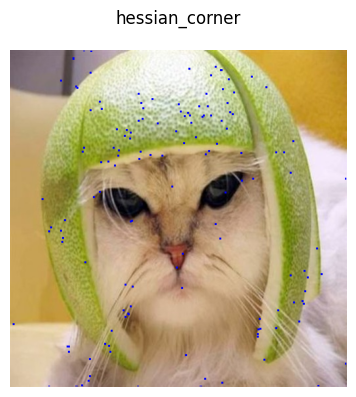

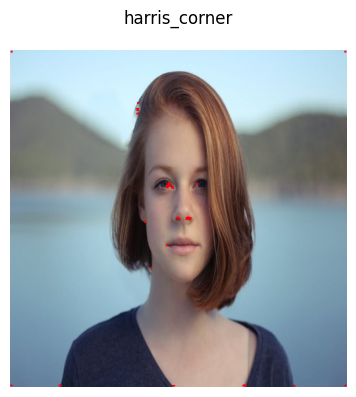

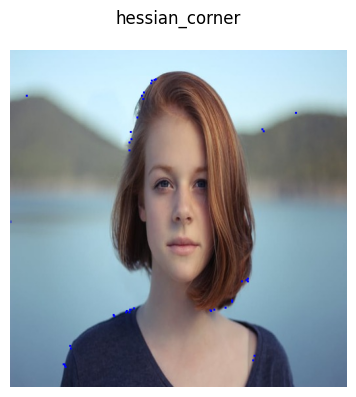

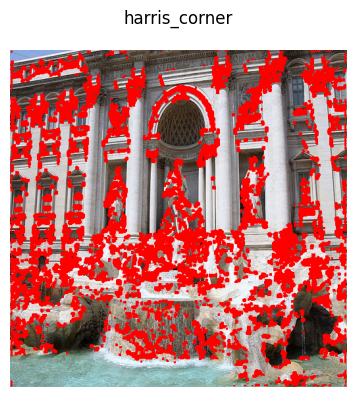

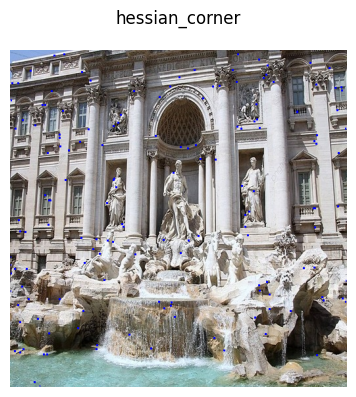

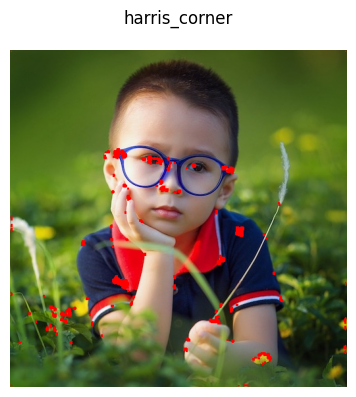

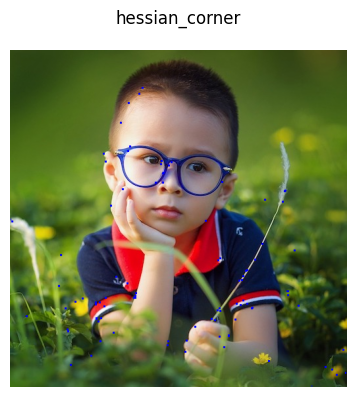

In [11]:
for image in gt_images:
    harris_corner = detect_harris_corner(image)
    hessian_corner = detect_hessian_corner(image)
    show_image_grid(harris_corner, 1, 1, 'harris_corner', figsize=16)
    show_image_grid(hessian_corner, 1, 1, 'hessian_corner', figsize=16)